<a href="https://colab.research.google.com/github/Blessed45-dev/BITCOIN-PRICE-PREDICTION/blob/main/Oguche_Blessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook Contents

1. Project Overview  
2. Environment Setup  
3. Document Upload  
4. OCR + NLP Pipeline  
5. Run OCR + NLP Pipeline
6. Results  
7. Exploratory Data Analysis  
8. Analysis Report

# HM Land Registry – Planning Document Processing

*Author:* Oguche Blessing  
*Challenge:* HM Land Registry Data Science Challenge  

This notebook implements an OCR + NLP pipeline to process scanned planning
permission documents and extract key information including:

- Page classification
- Application numbers
- Applicant names
- Document headings

#Environment Setup

In [4]:
!apt-get update
!apt-get install -y poppler-utils tesseract-ocr

!pip install pdf2image pytesseract pillow pandas spacy seaborn matplotlib
!python -m spacy download en_core_web_sm

Hit:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:2 https://cli.github.com/packages stable InRelease
Hit:3 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:5 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:6 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:7 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
poppler-utils is already the ne

#Document Upload

In [5]:
from google.colab import files
uploaded = files.upload()

Saving anonymised 1.pdf to anonymised 1.pdf


#OCR + NLP Pipeline

In [6]:
import json
import re
from collections import Counter
from pathlib import Path
from typing import Dict, List, Optional

import pandas as pd
import pytesseract
import spacy
from pdf2image import convert_from_path


# =========================================================
# 1) OCR
# =========================================================
def ocr_pdf(pdf_path: Path, dpi: int = 300, poppler_path: Optional[str] = None) -> List[str]:
    images = convert_from_path(
        str(pdf_path),
        dpi=dpi,
        poppler_path=poppler_path
    )

    page_texts = []
    config = "--oem 3 --psm 6"

    for img in images:
        text = pytesseract.image_to_string(img, config=config)
        page_texts.append(text or "")

    return page_texts


# =========================================================
# 2) TEXT NORMALISATION
# =========================================================
def normalise_ocr_text_for_refs(text: str) -> str:
    """
    Normalise OCR noise commonly seen in planning reference numbers.
    Examples:
        O2/8O/16O9 -> 02/80/1609
        02 / 80 / 1609 -> 02/80/1609
    """
    text = re.sub(r'(?<=\d)O(?=[/\d])', '0', text)
    text = re.sub(r'(?<=[/\d])O(?=\d)', '0', text)
    text = re.sub(r'(?<=\b)O(?=\d)', '0', text)
    text = re.sub(r'(?<=\d)O(?=\b)', '0', text)
    text = re.sub(r'\s*/\s*', '/', text)
    return text


# =========================================================
# 3) PAGE CLASSIFICATION
# =========================================================
def classify_page(text: str) -> str:
    t = " ".join(text.lower().split())

    if "planning charges" in t or ("part 3" in t and "charges" in t):
        return "planning_charges_register"

    if (
        "notice of approval of details" in t
        or ("notice of approval" in t and "details" in t)
        or "approval of details" in t
    ):
        return "notice_of_approval_of_details"

    if "grant of conditional planning permission" in t:
        return "grant_of_conditional_planning_permission"

    if (
        "application for planning permission" in t
        or ("notice of approval" in t and "particulars of application" in t)
        or "planning permission notice" in t
    ):
        return "planning_permission_notice_of_approval"

    return "other"


# =========================================================
# 4) HEADING IDENTIFICATION
# =========================================================
HEADING_PATTERNS = {
    "planning_charges": re.compile(r"\bplanning charges\b", re.IGNORECASE),
    "application_for_planning_permission": re.compile(r"\bapplication for planning permission\b", re.IGNORECASE),
    "notice_of_approval": re.compile(r"\bnotice of approval\b", re.IGNORECASE),
    "notice_of_approval_of_details": re.compile(r"\bnotice of approval of details\b", re.IGNORECASE),
    "grant_of_conditional_planning_permission": re.compile(r"\bgrant of conditional planning permission\b", re.IGNORECASE),
    "particulars_of_application": re.compile(r"\bpart(?:\s*i|\s*1)?\s*[-–]?\s*particulars of application\b", re.IGNORECASE),
    "particulars_of_decision": re.compile(r"\bpart(?:\s*ii|\s*2)?\s*[-–]?\s*particulars of decision\b", re.IGNORECASE),
    "applicant": re.compile(r"\bapplicant\b", re.IGNORECASE),
    "application_number": re.compile(r"\bapplication number\b", re.IGNORECASE),
}


def identify_headings(text: str) -> List[str]:
    found = []
    for heading_name, pattern in HEADING_PATTERNS.items():
        if pattern.search(text):
            found.append(heading_name)
    return found


# =========================================================
# 5) APPLICATION NUMBER EXTRACTION
# =========================================================
APP_NO_PATTERNS = [
    re.compile(r"\bP/\d{2}/\d{4}\b", re.IGNORECASE),  # P/00/0759
    re.compile(r"\b\d{2}/\d{2}/\d{4}\b"),            # 02/80/1609
]

DATE_RE = re.compile(r"^\d{1,2}/\d{1,2}/\d{4}$")


def looks_like_date(value: str) -> bool:
    if DATE_RE.match(value):
        return True

    parts = value.split("/")
    if len(parts) != 3:
        return False

    try:
        a = int(parts[0])
        b = int(parts[1])
        c = int(parts[2])
    except ValueError:
        return False

    return 1 <= a <= 31 and 1 <= b <= 12 and 1900 <= c <= 2100


def extract_application_numbers(text: str) -> List[str]:
    found = set()
    normalised_text = normalise_ocr_text_for_refs(text)

    for pat in APP_NO_PATTERNS:
        for m in pat.findall(normalised_text):
            candidate = m.strip().upper()
            if looks_like_date(candidate):
                continue
            found.add(candidate)

    return sorted(found)


# =========================================================
# 6) APPLICANT EXTRACTION
# =========================================================
BAD_PERSON_HINTS = [
    "director",
    "registrar",
    "secretary",
    "council",
    "planning authority",
    "signed",
    "yours faithfully",
    "for london borough",
    "for the council",
    "authority",
]

ADDRESS_WORDS = [
    "house", "road", "street", "st", "lane", "close", "avenue",
    "drive", "place", "centre", "hall", "annexe", "court",
    "way", "gardens", "crescent", "bypass", "park", "estate",
    "birmingham", "bristol", "london", "manchester", "devon",
    "east ham", "barnstaple", "roman road", "cunnery road"
]

APPLICANT_WORD_RE = re.compile(r"applicant", re.IGNORECASE)

TITLE_NAME_RE = re.compile(
    r"\b(?:Mr|Mrs|Miss|Ms|Dr)\s+(?:&\s*(?:Mr|Mrs|Miss|Ms)\s+)?[A-Z][A-Za-z\.]*"
    r"(?:\s+[A-Z][A-Za-z\.]*){0,4}",
    re.IGNORECASE
)


def looks_like_signatory_context(text: str) -> bool:
    t = text.lower()
    return any(word in t for word in BAD_PERSON_HINTS)


def looks_like_address(text: str) -> bool:
    t = text.lower()
    return any(word in t for word in ADDRESS_WORDS)


def clean_name(name: str) -> str:
    return re.sub(r"\s+", " ", name).strip(" ,;:")


def pick_best_person(persons: List[str]) -> Optional[str]:
    for p in persons:
        name = clean_name(p)
        tokens = name.split()

        if len(tokens) < 2 or len(tokens) > 8:
            continue

        if looks_like_signatory_context(name):
            continue

        if looks_like_address(name):
            continue

        return name

    return None


def extract_title_name_fallback(text: str) -> Optional[str]:
    for m in TITLE_NAME_RE.finditer(text):
        candidate = clean_name(m.group(0))
        if not looks_like_signatory_context(candidate) and not looks_like_address(candidate):
            return candidate
    return None


def extract_applicant_name(text: str, nlp) -> Optional[str]:
    lines = text.splitlines()

    # 1) Look around any "Applicant" line
    for i, line in enumerate(lines):
        if APPLICANT_WORD_RE.search(line):
            context = "\n".join(lines[i:i + 8])

            doc = nlp(context)
            persons = [ent.text for ent in doc.ents if ent.label_ == "PERSON"]
            best = pick_best_person(persons)
            if best:
                return best

            fallback = extract_title_name_fallback(context)
            if fallback:
                return fallback

            for j in range(i + 1, min(i + 5, len(lines))):
                raw = clean_name(lines[j])
                if re.match(r"^(Mr|Mrs|Miss|Ms|Dr)\b", raw, re.IGNORECASE):
                    if not looks_like_signatory_context(raw) and not looks_like_address(raw):
                        return raw

    # 2) Whole-page title fallback
    fallback = extract_title_name_fallback(text)
    if fallback:
        return fallback

    # 3) Whole-page NER fallback
    if not looks_like_signatory_context(text):
        doc = nlp(text)
        persons = [ent.text for ent in doc.ents if ent.label_ == "PERSON"]
        best = pick_best_person(persons)
        if best:
            return best

    # 4) Final compact fallback
    title_match = re.search(
        r"\b(Mr|Mrs|Miss|Ms|Dr)\s+[A-Z][A-Za-z\.]\s(?:[A-Z][A-Za-z\.]*)?",
        text,
        re.IGNORECASE,
    )

    if title_match:
        candidate = clean_name(title_match.group(0))
        if not looks_like_signatory_context(candidate) and not looks_like_address(candidate):
            return candidate

    return None


# =========================================================
# 7) DIAGNOSTIC NOTES
# =========================================================
def build_extraction_notes(
    page_type: str,
    applicant: Optional[str],
    apps: List[str],
    text: str,
) -> List[str]:
    notes = []

    if not apps:
        notes.append("no_application_number_found")

    if applicant is None:
        notes.append("no_applicant_found")

    if page_type == "planning_charges_register":
        notes.append("register_page_may_have_noisy_tabular_ocr")

    if len(text.strip()) < 80:
        notes.append("low_text_volume")

    return notes


# =========================================================
# 8) FORMATTED REPORT
# =========================================================
def print_analysis_report(pdf_path: Path, results: List[Dict]) -> None:
    print("\n" + "=" * 70)
    print("HM LAND REGISTRY - PLANNING DOCUMENT ANALYSIS REPORT")
    print("=" * 70)

    print(f"\nDocument: {pdf_path}")
    print(f"Total Pages: {len(results)}")

    print("\n--- PAGE CLASSIFICATION ---")
    page_types = [r["page_type"] for r in results]
    counts = Counter(page_types)

    for page_type, count in counts.items():
        pages = [r["page_number"] for r in results if r["page_type"] == page_type]
        print(f"  {page_type}: {count} page(s) - Pages {pages}")

    print("\n--- PAGE-BY-PAGE EXTRACTION ---")
    for r in results:
        print(
            f"  Page {r['page_number']}: "
            f"type={r['page_type']} | "
            f"applicant={r['applicant_name']} | "
            f"application_numbers={r['application_numbers']} | "
            f"notes={r['extraction_notes']}"
        )

    unique_app_numbers = sorted({
        app
        for r in results
        for app in r["application_numbers"]
    })

    print("\n--- UNIQUE APPLICATION NUMBERS ---")
    for i, app in enumerate(unique_app_numbers, start=1):
        print(f"  {i}. {app}")

    unique_applicants = sorted({
        r["applicant_name"]
        for r in results
        if r["applicant_name"]
    })

    print("\n--- UNIQUE APPLICANT NAMES ---")
    for i, name in enumerate(unique_applicants, start=1):
        print(f"  {i}. {name}")


# =========================================================
# 9) MAIN PIPELINE
# =========================================================
def run(
    pdf_path: Path,
    out_dir: Path,
    dpi: int = 300,
    poppler_path: Optional[str] = None,
    tesseract_cmd: Optional[str] = None
) -> List[Dict]:
    out_dir.mkdir(parents=True, exist_ok=True)

    if tesseract_cmd:
        pytesseract.pytesseract.tesseract_cmd = tesseract_cmd

    print(f"Reading PDF: {pdf_path}")
    page_texts = ocr_pdf(pdf_path=pdf_path, dpi=dpi, poppler_path=poppler_path)
    print(f"OCR complete. Pages: {len(page_texts)}")

    nlp = spacy.load("en_core_web_sm")

    results: List[Dict] = []

    for idx, text in enumerate(page_texts):
        page_type = classify_page(text)
        application_numbers = extract_application_numbers(text)
        applicant_name = extract_applicant_name(text, nlp)
        headings_found = identify_headings(text)
        notes = build_extraction_notes(page_type, applicant_name, application_numbers, text)

        row = {
            "page_index": idx,
            "page_number": idx + 1,
            "page_type": page_type,
            "headings_found": headings_found,
            "application_numbers": application_numbers,
            "application_number_count": len(application_numbers),
            "applicant_name": applicant_name,
            "has_applicant": applicant_name is not None,
            "extraction_notes": "; ".join(notes) if notes else "",
        }
        results.append(row)

    json_path = out_dir / "results.json"
    csv_path = out_dir / "results.csv"
    ocr_path = out_dir / "ocr_text_by_page.json"

    json_path.write_text(json.dumps(results, indent=2), encoding="utf-8")
    pd.DataFrame(results).to_csv(csv_path, index=False)
    ocr_path.write_text(json.dumps(page_texts, indent=2), encoding="utf-8")

    print(f"Saved: {json_path}")
    print(f"Saved: {csv_path}")
    print(f"Saved: {ocr_path}")

    print_analysis_report(pdf_path, results)

    return results

#Run OCR + NLP Pipeline

In [7]:
from pathlib import Path

results = run(
    pdf_path=Path("/content/anonymised 1.pdf"),
    out_dir=Path("out"),
    dpi=300,
    poppler_path=None,
    tesseract_cmd=None
)

Reading PDF: /content/anonymised 1.pdf
OCR complete. Pages: 4
Saved: out/results.json
Saved: out/results.csv
Saved: out/ocr_text_by_page.json

HM LAND REGISTRY - PLANNING DOCUMENT ANALYSIS REPORT

Document: /content/anonymised 1.pdf
Total Pages: 4

--- PAGE CLASSIFICATION ---
  planning_charges_register: 1 page(s) - Pages [1]
  planning_permission_notice_of_approval: 1 page(s) - Pages [2]
  grant_of_conditional_planning_permission: 1 page(s) - Pages [3]
  notice_of_approval_of_details: 1 page(s) - Pages [4]

--- PAGE-BY-PAGE EXTRACTION ---
  Page 1: type=planning_charges_register | applicant=None | application_numbers=[] | notes=no_application_number_found; no_applicant_found; register_page_may_have_noisy_tabular_ocr
  Page 2: type=planning_permission_notice_of_approval | applicant=Mr M Dale | application_numbers=['P/00/0759'] | notes=
  Page 3: type=grant_of_conditional_planning_permission | applicant=None | application_numbers=[] | notes=no_application_number_found; no_applicant_foun

#Results

In [8]:
import pandas as pd

df = pd.read_csv("out/results.csv")
df

,page_index,page_number,page_type,headings_found,application_numbers,application_number_count,applicant_name,has_applicant,extraction_notes
0,0,1,planning_charges_register,[],[],0,NaN,False,no_application_number_found; no_applicant_foun...
1,1,2,planning_permission_notice_of_approval,"['notice_of_approval', 'application_number']",['P/00/0759'],1,Mr M Dale,True,NaN
2,2,3,grant_of_conditional_planning_permission,"['grant_of_conditional_planning_permission', '...",[],0,NaN,False,no_application_number_found; no_applicant_found
3,3,4,notice_of_approval_of_details,"['notice_of_approval', 'applicant', 'applicati...","['P/96/0900', 'P/98/0964']",2,NaN,False,no_applicant_found


In [9]:
def pipeline_summary_statistics(results):
    import pandas as pd

    df = pd.DataFrame(results)

    stats = {
        "total_pages": len(df),
        "pages_with_application_number": df["application_number_count"].gt(0).sum(),
        "pages_with_applicant": df["has_applicant"].sum(),
        "pages_missing_application_number": df["application_number_count"].eq(0).sum(),
        "pages_missing_applicant": (~df["has_applicant"]).sum(),
        "unique_application_numbers": df["application_numbers"].explode().nunique(),
        "unique_applicants": df["applicant_name"].nunique(),
    }

    return pd.DataFrame(stats, index=["pipeline_summary"])

In [10]:
summary = pipeline_summary_statistics(results)
summary

,total_pages,pages_with_application_number,pages_with_applicant,pages_missing_application_number,pages_missing_applicant,unique_application_numbers,unique_applicants
pipeline_summary,4,2,1,2,3,3,1


#EDA Visualisations

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#Application Numbers Extracted




In [12]:
df["application_number_count"].describe()

,application_number_count
count,4.000000
mean,0.750000
std,0.957427
min,0.000000
25%,0.000000
50%,0.500000
75%,1.250000
max,2.000000


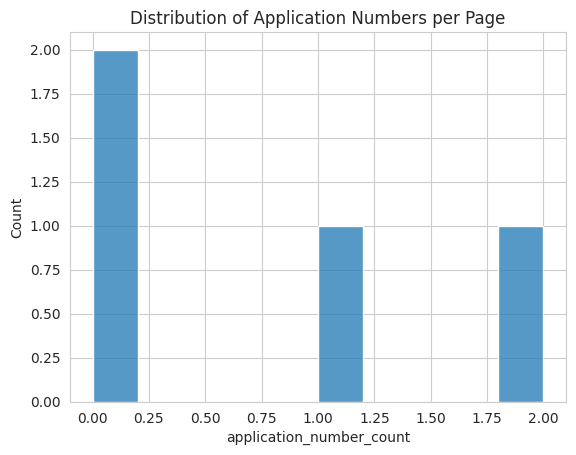

In [13]:
sns.set_style("whitegrid")

sns.histplot(df["application_number_count"], bins=10)

plt.title("Distribution of Application Numbers per Page")
plt.show()

#Pages with Extraction Issues

In [14]:
df[df["extraction_notes"] != ""]

,page_index,page_number,page_type,headings_found,application_numbers,application_number_count,applicant_name,has_applicant,extraction_notes
0,0,1,planning_charges_register,[],[],0,NaN,False,no_application_number_found; no_applicant_foun...
1,1,2,planning_permission_notice_of_approval,"['notice_of_approval', 'application_number']",['P/00/0759'],1,Mr M Dale,True,NaN
2,2,3,grant_of_conditional_planning_permission,"['grant_of_conditional_planning_permission', '...",[],0,NaN,False,no_application_number_found; no_applicant_found
3,3,4,notice_of_approval_of_details,"['notice_of_approval', 'applicant', 'applicati...","['P/96/0900', 'P/98/0964']",2,NaN,False,no_applicant_found


#Heading Detection Analysis

In [15]:
df["headings_found"]

,headings_found
0,[]
1,"['notice_of_approval', 'application_number']"
2,"['grant_of_conditional_planning_permission', '..."
3,"['notice_of_approval', 'applicant', 'applicati..."


In [16]:
from collections import Counter

all_headings = []

for h in df["headings_found"].dropna():
    if isinstance(h, str):
        continue
    all_headings.extend(h)

Counter(all_headings)

Counter()

#OCR Text Length Analysis

In [17]:
import json

with open("out/ocr_text_by_page.json") as f:
    ocr_pages = json.load(f)

lengths = [len(t) for t in ocr_pages]

lengths

[1797, 1637, 3596, 1114]

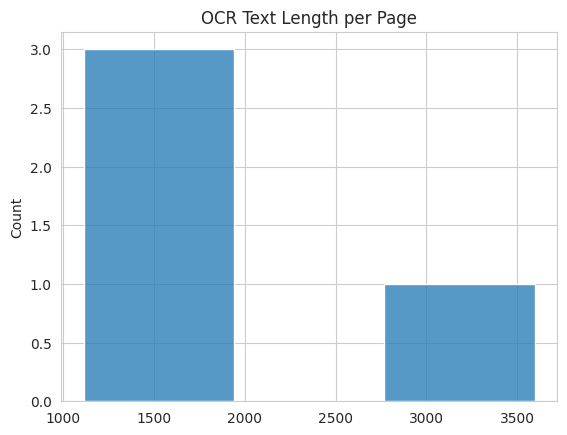

In [18]:
sns.histplot(lengths)

plt.title("OCR Text Length per Page")
plt.show()

#Extraction Success Heatmap

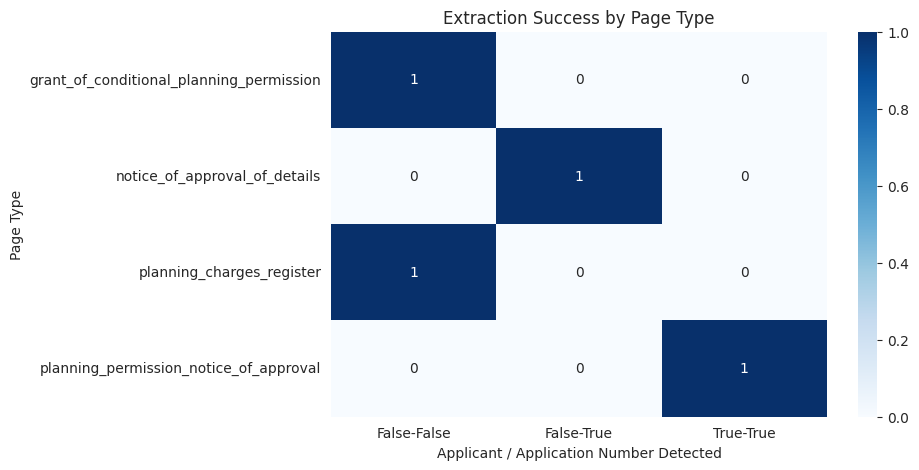

In [19]:
df["has_applicant"] = df["applicant_name"].notna()
df["has_application_number"] = df["application_numbers"].astype(str).str.len() > 2

pivot = pd.pivot_table(
    df,
    values="page_number",
    index="page_type",
    columns=["has_applicant", "has_application_number"],
    aggfunc="count",
    fill_value=0
)

plt.figure(figsize=(8,5))

sns.heatmap(
    pivot,
    annot=True,
    cmap="Blues"
)

plt.title("Extraction Success by Page Type")
plt.ylabel("Page Type")
plt.xlabel("Applicant / Application Number Detected")

plt.show()

#Analysis Report

#Analysis Report
###HM Land Registry Planning Document Processing
###Overview

This project implements an OCR-based natural language processing pipeline to analyse scanned planning decision notices. The goal is to classify page types and extract key information including planning application numbers and applicant names.

Because the documents are scanned PDFs rather than machine-readable text, the pipeline first converts the PDF pages into images and then applies optical character recognition (OCR) before performing text analysis.

The overall processing pipeline consists of the following steps:

PDF Rendering – The input PDF is converted to page images using pdf2image.

OCR Extraction – Text is extracted from each page using Tesseract OCR.

Page Classification – Pages are categorised into document types using rule-based keyword detection.

Heading Detection – Key structural headings are identified using regex patterns.

Application Number Extraction – Planning reference numbers are extracted using regex patterns with OCR normalisation.

Applicant Name Extraction – Applicant names are extracted using spaCy Named Entity Recognition (NER) with rule-based fallbacks.

Diagnostics & Reporting – Extraction notes and summary reports are generated to support transparency and debugging.

The pipeline produces structured outputs in CSV and JSON format, as well as a human-readable console report.

###Exploratory Data Analysis (EDA)

The sample document contains four pages, each representing a different planning document section.

The page classification results are:

Page	Type
1	Planning Charges Register
2	Planning Permission Notice of Approval
3	Grant of Conditional Planning Permission
4	Notice of Approval of Details

Three unique planning application numbers were extracted:

P/00/0759
P/96/0900
P/98/0964

One applicant name was successfully identified:

Mr M Dale

The register page contained tabular data, which produced noisy OCR output. As expected, no applicant names or application numbers were reliably extracted from this page.

Overall extraction results demonstrate that rule-based patterns combined with NER provide reliable information extraction for decision notice pages.

###Limitations

Several limitations were observed during development:

#####OCR Quality

OCR accuracy can vary depending on scan quality, resolution, and document layout. Tabular pages such as the planning charges register produce fragmented text which reduces extraction reliability.

#####Layout Sensitivity

The solution uses keyword rules rather than layout-aware models. If document formatting changes significantly, classification accuracy may decrease.

#####Applicant Detection

Applicant names are extracted using NER with rule-based filtering. If the applicant appears in unusual formats or without titles (e.g., “Mr”, “Ms”), detection accuracy may be reduced.

#####Small Dataset

The approach is tuned for the provided sample document and may require adjustments when applied to larger or more diverse datasets.

###Potential Improvements

Several improvements could further increase robustness:

#####Layout-Aware Models

Models such as LayoutLM or LayoutLMv3 could incorporate spatial document structure to improve information extraction.

#####Table Extraction

Libraries such as Camelot or Tabula could better process tabular planning register pages.

#####Fine-Tuned NER

Training a custom NER model for planning entities (e.g., applicants, planning authorities, reference numbers) would improve extraction accuracy.

#####OCR Preprocessing

Image preprocessing techniques such as binarisation, noise removal, and deskewing could improve OCR quality.

###Conclusion

The implemented OCR-NLP pipeline successfully processes scanned planning decision notices, classifies page types, and extracts key planning information. While the rule-based approach performs well on the provided document, future improvements could leverage layout-aware models and domain-specific NER to improve generalisation across diverse planning documents.